# Melhoria 2 (cumulativa) — Divisão Estratificada + Balanceamento

Este notebook combina DUAS melhorias sobre a replicação original:
1. **Balanceamento de classes** (class weight) — já aplicado no notebook `03`.
2. **Divisão estratificada** (nova) — garante proporção 80/20 exata dentro de cada classe.

## Por que mudar o carregamento
O `image_dataset_from_directory(validation_split=...)` usado nos notebooks anteriores divide os dados sem considerar a classe (não é estratificado). A proporção 80/20 por classe que obtivemos antes foi aproximada, por acaso. Aqui montamos a divisão manualmente com `train_test_split(stratify=...)` do scikit-learn, assegurando a proporção exata em todas as classes — o que é especialmente relevante para a Tuberculosis, a classe minoritária.

## Metodologia
Arquitetura, seed, otimizador e demais parâmetros permanecem idênticos aos notebooks anteriores. As únicas mudanças são a forma de dividir os dados (estratificada) e a presença do class weight.

## 1. Importação das bibliotecas

Além das bibliotecas usuais, importamos `train_test_split` (para a divisão estratificada) e `pathlib` (para listar os arquivos de imagem).

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pathlib

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow versão:", tf.__version__)

I0000 00:00:1791483935.273784    1190 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791483935.747206    1190 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791483937.801604    1190 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow versão: 2.21.0


## 2. Listagem dos arquivos e rótulos

Percorremos a pasta `dataset_unificado` e montamos duas listas paralelas: o caminho de cada imagem e o número da sua classe (0 = COVID-19, 1 = Normal, 2 = Pneumonia, 3 = Tuberculosis). É a partir dessas listas que faremos a divisão estratificada.

In [2]:
diretorio = pathlib.Path("dataset_unificado")

# Nomes das classes em ordem alfabética (mesma ordem que o Keras usava)
nomes_classes = sorted([p.name for p in diretorio.iterdir() if p.is_dir()])
print("Classes:", nomes_classes)

# Monta as listas paralelas: caminho da imagem + rótulo (número da classe)
caminhos = []
rotulos = []
for indice, classe in enumerate(nomes_classes):
    for arquivo in (diretorio / classe).glob("*"):
        caminhos.append(str(arquivo))
        rotulos.append(indice)

print("Total de imagens encontradas:", len(caminhos))

Classes: ['COVID-19', 'Normal', 'Pneumonia', 'Tuberculosis']
Total de imagens encontradas: 18781


## 3. Divisão estratificada (80/20 por classe)

Usamos `train_test_split` com `stratify=rotulos`. Esse parâmetro é o que garante a estratificação: o scikit-learn separa 20% para teste dentro de cada classe individualmente, preservando a proporção original. `random_state=42` mantém a divisão reproduzível. Em seguida conferimos a contagem por classe no treino.

In [3]:
caminhos_treino, caminhos_teste, rotulos_treino, rotulos_teste = train_test_split(
    caminhos,
    rotulos,
    test_size=0.2,
    stratify=rotulos,   # <<< a estratificação acontece aqui
    random_state=42
)

print("Imagens de treino:", len(caminhos_treino))
print("Imagens de teste: ", len(caminhos_teste))

# Conferindo a contagem por classe no TREINO
rotulos_treino = np.array(rotulos_treino)
print("\nDistribuição no treino:")
valores, contagens = np.unique(rotulos_treino, return_counts=True)
for v, c in zip(valores, contagens):
    print(f"  {nomes_classes[v]}: {c} imagens")

Imagens de treino: 15024
Imagens de teste:  3757

Distribuição no treino:
  COVID-19: 2893 imagens
  Normal: 8153 imagens
  Pneumonia: 3418 imagens
  Tuberculosis: 560 imagens


## 4. Construção dos datasets do TensorFlow

Como agora temos listas de caminhos (e não uma pasta lida automaticamente), definimos uma função que, dado o caminho de uma imagem, a abre, decodifica, redimensiona para 300×300 e a entrega junto com seu rótulo. A partir dela montamos os datasets de treino e teste.

- `channels=3` força RGB (igual ao padrão do notebook anterior).
- O treino é embaralhado a cada época (`shuffle`) para um aprendizado melhor.
- `batch(32)` agrupa em lotes de 32, como antes.

In [4]:
TAMANHO_IMAGEM = (300, 300)
TAMANHO_LOTE = 32

# Função que abre uma imagem a partir do caminho e a prepara
def carregar_imagem(caminho, rotulo):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, TAMANHO_IMAGEM)
    return img, rotulo

# Dataset de TREINO (embaralhado a cada época)
dataset_treino = tf.data.Dataset.from_tensor_slices((caminhos_treino, list(rotulos_treino)))
dataset_treino = dataset_treino.shuffle(buffer_size=len(caminhos_treino), seed=42)
dataset_treino = dataset_treino.map(carregar_imagem).batch(TAMANHO_LOTE)

# Dataset de TESTE (sem embaralhar)
dataset_teste = tf.data.Dataset.from_tensor_slices((caminhos_teste, list(rotulos_teste)))
dataset_teste = dataset_teste.map(carregar_imagem).batch(TAMANHO_LOTE)

# Teste rápido: pega 1 lote e confere o formato
for imagens, rotulos_lote in dataset_treino.take(1):
    print("Formato do lote de imagens:", imagens.shape)
    print("Formato do lote de rótulos:", rotulos_lote.shape)

E0000 00:00:1791483939.858261    1190 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Formato do lote de imagens: (32, 300, 300, 3)
Formato do lote de rótulos: (32,)


## 5. Cálculo dos pesos das classes

Recalculamos os pesos com `compute_class_weight("balanced")`, agora sobre os rótulos do treino estratificado. Como a distribuição mudou ligeiramente em relação ao notebook `03`, os pesos também mudam um pouco. É o mesmo balanceamento do notebook `03`, aplicado sobre a nova divisão.

In [5]:
pesos_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(rotulos_treino),
    y=rotulos_treino
)

pesos_classes = {i: peso for i, peso in enumerate(pesos_array)}

print("Pesos calculados por classe:\n")
for i, peso in pesos_classes.items():
    print(f"  {nomes_classes[i]} ({contagens[i]} imagens): peso = {peso:.4f}")

Pesos calculados por classe:

  COVID-19 (2893 imagens): peso = 1.2983
  Normal (8153 imagens): peso = 0.4607
  Pneumonia (3418 imagens): peso = 1.0989
  Tuberculosis (560 imagens): peso = 6.7071


## 6. Construção do modelo

Arquitetura idêntica à da Tabela 3 do artigo (mesma dos notebooks `02` e `03`). Nada muda aqui — isolar a arquitetura é o que permite atribuir qualquer diferença às melhorias de dados. Total: 3.047.460 parâmetros.

In [6]:
modelo = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(300, 300, 3)),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

modelo.summary()

/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,047,460 (11.63 MB)

 Trainable params: 3,047,460 (11.63 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compilação e treino

Compilação idêntica aos notebooks anteriores. O treino usa `class_weight=pesos_classes` (o balanceamento). O melhor modelo é salvo em `melhor_modelo_estratificado_balanceado.keras` — nome próprio, para não sobrescrever os modelos dos notebooks `02` e `03` e permitir a comparação final entre os três.

In [7]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "melhor_modelo_estratificado_balanceado.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

import time
inicio = time.time()

historico = modelo.fit(
    dataset_treino,
    validation_data=dataset_teste,
    epochs=30,
    callbacks=[checkpoint],
    class_weight=pesos_classes
)

fim = time.time()
print(f"\nTempo total para 30 épocas: {(fim-inicio)/60:.1f} minutos")

/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.7652 - loss: 0.5828
Epoch 1: val_accuracy improved from None to 0.87943, saving model to melhor_modelo_estratificado_balanceado.keras

Epoch 1: finished saving model to melhor_modelo_estratificado_balanceado.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.7652 - loss: 0.5828 - val_accuracy: 0.8794 - val_loss: 0.3116
Epoch 2/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9004 - loss: 0.2556
Epoch 2: val_accuracy improved from 0.87943 to 0.92068, saving model to melhor_modelo_estratificado_balanceado.keras

Epoch 2: finished saving model to melhor_modelo_estratificado_balanceado.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 503s 1s/step - accuracy: 0.9004 - loss: 0.2556 - val_accuracy: 0.9207 - val_loss: 0.2272
Epoch 3/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9313 - loss: 0.1761
Epoch 3: val_accuracy improved from 0.92068 to 0.92627, saving model to melhor_modelo_estratificado_balanceado.kera

## 8. Avaliação do modelo

Carregamos o melhor modelo salvo e geramos as previsões sobre o conjunto de teste estratificado, montando o relatório por classe e a matriz de confusão — nos mesmos moldes dos notebooks anteriores, para comparação direta.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

melhor_modelo = keras.models.load_model("melhor_modelo_estratificado_balanceado.keras")

y_verdadeiro = []
y_previsto = []

for imagens, rotulos_lote in dataset_teste:
    previsoes = melhor_modelo.predict(imagens, verbose=0)
    y_verdadeiro.extend(rotulos_lote.numpy())
    y_previsto.extend(np.argmax(previsoes, axis=1))

y_verdadeiro = np.array(y_verdadeiro)
y_previsto = np.array(y_previsto)

print(classification_report(
    y_verdadeiro, y_previsto,
    target_names=nomes_classes,
    digits=4
))

              precision    recall  f1-score   support

    COVID-19     0.9507    0.9599    0.9553       723
      Normal     0.9843    0.9858    0.9851      2039
   Pneumonia     0.9976    0.9883    0.9929       855
Tuberculosis     0.9565    0.9429    0.9496       140

    accuracy                         0.9798      3757
   macro avg     0.9723    0.9692    0.9707      3757
weighted avg     0.9798    0.9798    0.9798      3757



## 9. Matriz de confusão

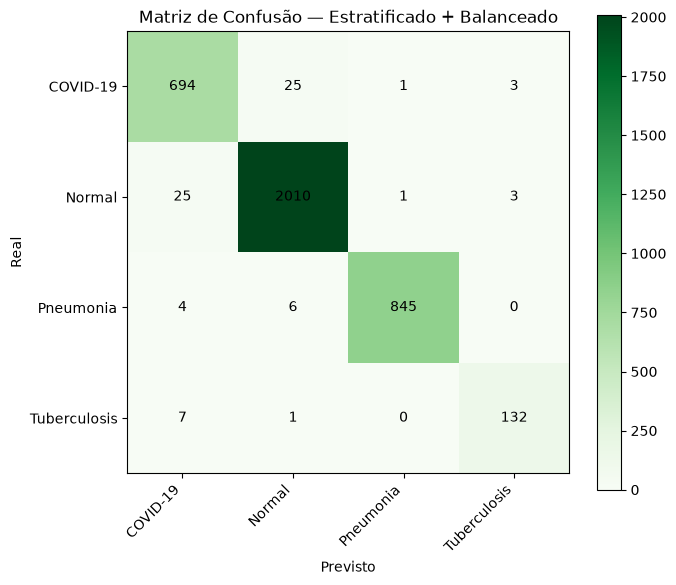

In [9]:
matriz = confusion_matrix(y_verdadeiro, y_previsto)

plt.figure(figsize=(7, 6))
plt.imshow(matriz, cmap="Greens")
plt.colorbar()
plt.xticks(range(4), nomes_classes, rotation=45, ha="right")
plt.yticks(range(4), nomes_classes)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão — Estratificado + Balanceado")

for i in range(4):
    for j in range(4):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [10]:
import random, pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras

# --- troque aqui para testar cada modelo ---
CAMINHO_MODELO = "melhor_modelo_estratificado_balanceado.keras"
# CAMINHO_MODELO = "melhor_modelo_balanceado.keras"

modelo_teste = keras.models.load_model(CAMINHO_MODELO)

diretorio = pathlib.Path("dataset_unificado")
nomes_classes = sorted([p.name for p in diretorio.iterdir() if p.is_dir()])

N_POR_CLASSE = 25
random.seed(42)   # mesma seleção de imagens para os dois modelos -> comparação justa

def preparar(caminho):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (300, 300))
    return tf.expand_dims(img, 0)   # transforma em um "lote" de 1 imagem

print(f"Teste amostral — {N_POR_CLASSE} imagens por classe")
print(f"Modelo: {CAMINHO_MODELO}\n")

total_acertos = 0
for indice, classe in enumerate(nomes_classes):
    arquivos = list((diretorio / classe).glob("*"))
    amostra = random.sample(arquivos, N_POR_CLASSE)
    acertos = sum(
        int(np.argmax(modelo_teste.predict(preparar(str(arq)), verbose=0))) == indice
        for arq in amostra
    )
    print(f"  {classe}: {acertos}/{N_POR_CLASSE}")
    total_acertos += acertos

print(f"\nTotal: {total_acertos}/{100} ({total_acertos}%)")

Teste amostral — 25 imagens por classe
Modelo: melhor_modelo_estratificado_balanceado.keras

  COVID-19: 24/25
  Normal: 24/25
  Pneumonia: 25/25
  Tuberculosis: 25/25

Total: 98/100 (98%)
